In [1]:
!pip install pennylane
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu


In [2]:
import os, random, shutil, pickle, time
import numpy as np
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pennylane as qml

from tqdm import tqdm

# reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# device for classical parts
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


In [3]:
# Put your images in three class folders:
# <DATA_ROOT>/no_pothole, <DATA_ROOT>/minor, <DATA_ROOT>/severe

DATA_ROOT = r"D:\rdd_severity_dataset"

for c in ["no_pothole","minor","severe"]:
    os.makedirs(os.path.join(DATA_ROOT, c), exist_ok=True)

# Quick sanity counts
def count_images(root):
    tot = {}
    for c in sorted(os.listdir(root)):
        p = os.path.join(root, c)
        if os.path.isdir(p):
            tot[c] = len([f for f in os.listdir(p) if f.lower().endswith(('.jpg','.png','.jpeg'))])
    return tot

print("Class counts (put images if zero):", count_images(DATA_ROOT))


Class counts (put images if zero): {'minor': 815, 'no_pothole': 720, 'severe': 1402}


In [4]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

dataset = ImageFolder(DATA_ROOT, transform=transform)
print("Classes:", dataset.classes)
print("Total images:", len(dataset))

# build file list and labels
paths = [p for p,_ in dataset.samples]
labels = np.array([lab for _,lab in dataset.samples])

# stratified split on indices: train 70%, val 10%, test 20%
train_idx, test_idx = train_test_split(np.arange(len(labels)), test_size=0.20, stratify=labels, random_state=SEED)
train_idx, val_idx = train_test_split(train_idx, test_size=0.125, stratify=labels[train_idx], random_state=SEED) # 0.125*0.8=0.1

print("Train/Val/Test:", len(train_idx), len(val_idx), len(test_idx))

# save split info for reproducibility
os.makedirs("exp", exist_ok=True)
pickle.dump({"train_idx":train_idx, "val_idx":val_idx, "test_idx":test_idx, "paths":paths, "labels":labels.tolist()}, open("exp/split_info.pkl","wb"))


Classes: ['minor', 'no_pothole', 'severe']
Total images: 2937
Train/Val/Test: 2055 294 588


In [5]:
# create loader (preserve ordering)
full_loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=4)

# ResNet50 pretrained feature extractor
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1]).to(DEVICE).eval()

embs_list = []
labs_list = []
with torch.no_grad():
    for imgs, labs in tqdm(full_loader, desc="Extracting embeddings"):
        imgs = imgs.to(DEVICE)
        feats = feature_extractor(imgs)          # (B,2048,1,1)
        feats = feats.view(feats.size(0), -1)   # (B,2048)
        embs_list.append(feats.cpu().numpy())
        labs_list.append(labs.numpy())

X = np.vstack(embs_list)   # (N, 2048)
y = np.hstack(labs_list)
pickle.dump(paths, open("exp/image_paths.pkl","wb"))
np.save("exp/embeddings.npy", X)
np.save("exp/labels.npy", y)
print("Saved embeddings shape:", X.shape)


Extracting embeddings: 100%|███████████████████████████████████████████████████████████| 92/92 [00:33<00:00,  2.76it/s]

Saved embeddings shape: (2937, 2048)


In [6]:
X = np.load("exp/embeddings.npy")
y = np.load("exp/labels.npy")
paths = pickle.load(open("exp/image_paths.pkl","rb"))
split = pickle.load(open("exp/split_info.pkl","rb"))
train_idx, val_idx, test_idx = split["train_idx"], split["val_idx"], split["test_idx"]

n_qubits = 6   # choose 4,6,8 depending on circuit capacity
pca = PCA(n_components=n_qubits, random_state=SEED)
X_reduced = pca.fit_transform(X)

scaler = StandardScaler()
X_std = scaler.fit_transform(X_reduced)
X_min, X_max = X_std.min(), X_std.max()
X_scaled = (X_std - X_min) / (X_max - X_min) * np.pi   # [0, pi] for angle encoding

# Save transformers
joblib.dump(pca, "exp/pca.joblib")
joblib.dump(scaler, "exp/scaler.joblib")

# create arrays per split
X_train, y_train = X_scaled[train_idx], y[train_idx]
X_val,   y_val   = X_scaled[val_idx],   y[val_idx]
X_test,  y_test  = X_scaled[test_idx],  y[test_idx]

print("Train/Val/Test shapes:", X_train.shape, X_val.shape, X_test.shape)


Train/Val/Test shapes: (2055, 6) (294, 6) (588, 6)


In [3]:
# ===== Cell 6: Batched TorchLayer QNN training (full-run) =====
import os, time, joblib
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pennylane as qml

# -----------------------
# 0. Load required arrays if not in memory
# -----------------------
if 'X_train' not in globals():
    print("Loading processed artifacts from exp/ ...")
    X_train = joblib.load("exp/dataset_processed.joblib")["X_train"]
    y_train = joblib.load("exp/dataset_processed.joblib")["y_train"]
    # fallback to numpy files
    try:
        X_train = np.load("exp/X_train.npy")
        y_train = np.load("exp/y_train.npy")
    except Exception:
        pass

# try loading explicit saved arrays (common names used earlier)
if 'X_train' not in globals() or X_train is None:
    # fallback to previous saved split variables if exist
    X = np.load("exp/embeddings.npy")
    y = np.load("exp/labels.npy")
    split = __import__('pickle').load(open("exp/split_info.pkl","rb"))
    pca = joblib.load("exp/pca.joblib")
    scaler = joblib.load("exp/scaler.joblib")
    X_reduced = pca.transform(X)
    X_std = scaler.transform(X_reduced)
    X_min, X_max = X_std.min(), X_std.max()
    X_scaled = (X_std - X_min) / (X_max - X_min) * np.pi
    train_idx, val_idx, test_idx = split["train_idx"], split["val_idx"], split["test_idx"]
    X_train, y_train = X_scaled[train_idx], np.array(split["labels"])[train_idx]
    X_val, y_val = X_scaled[val_idx], np.array(split["labels"])[val_idx]
    X_test, y_test = X_scaled[test_idx], np.array(split["labels"])[test_idx]

# ensure numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)
print("Shapes (train/test):", X_train.shape, X_test.shape)

# -----------------------
# 1. Hyperparams & device choices
# -----------------------
n_qubits = int(X_train.shape[1])            # number of PCA components used
n_layers = 2                                # variational layers
batch_size = 16                             # small batch to keep sim time reasonable
epochs = 30
lr = 0.02
device = torch.device("cpu")                # Run QNN on CPU (default.qubit)

# -----------------------
# 2. Build Pennylane QNode + TorchLayer
# -----------------------
dev = qml.device("default.qubit", wires=n_qubits)

weight_shapes = {"weights": (n_layers, n_qubits, 3)}

@qml.qnode(dev, interface="torch", diff_method="backprop")
def qnode_torch(inputs, weights):
    # inputs: shape (n_qubits,) per sample (TorchLayer will handle batch internally)
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    # return expectation per qubit -> vector of length n_qubits
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# TorchLayer wraps the QNode and exposes trainable weights as torch Parameters
qlayer = qml.qnn.TorchLayer(qnode_torch, weight_shapes)

# -----------------------
# 3. Hybrid model (TorchLayer + small classical head)
# -----------------------
class HybridQNN_TorchLayer(nn.Module):
    def __init__(self, qlayer, n_qubits, n_classes):
        super().__init__()
        self.qlayer = qlayer                 # maps (batch, n_qubits) -> (batch, n_qubits)
        self.fc = nn.Sequential(
            nn.Linear(n_qubits, 32),
            nn.ReLU(),
            nn.Linear(32, n_classes)
        )
    def forward(self, x):
        # Expect x on same device as qlayer inputs (CPU here)
        q_out = self.qlayer(x)               # (batch, n_qubits)
        logits = self.fc(q_out)
        return logits

n_classes = len(np.unique(y_train))
model = HybridQNN_TorchLayer(qlayer, n_qubits=n_qubits, n_classes=n_classes).to(device)
print("Model instantiated. #params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

# -----------------------
# 4. Prepare DataLoaders (CPU tensors)
# -----------------------
Xtr_t = torch.tensor(X_train, dtype=torch.float32)
ytr_t = torch.tensor(y_train, dtype=torch.long)
Xte_t = torch.tensor(X_test, dtype=torch.float32)
yte_t = torch.tensor(y_test, dtype=torch.long)

train_ds = TensorDataset(Xtr_t, ytr_t)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

# -----------------------
# 5. Training loop
# -----------------------
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

train_losses = []
start_time = time.time()
for epoch in range(1, epochs+1):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        out = model(xb)                   # qlayer handles batch internally
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    epoch_loss = float(np.mean(batch_losses))
    train_losses.append(epoch_loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f"[Epoch {epoch}/{epochs}] loss: {epoch_loss:.4f}")
total_time = time.time() - start_time
print(f"Training finished in {total_time:.1f} sec ({total_time/epochs:.2f} sec/epoch)")

# -----------------------
# 6. Evaluation on test set (final)
# -----------------------
model.eval()
with torch.no_grad():
    logits_test = model(Xte_t.to(device))
    preds = torch.argmax(logits_test, dim=1).cpu().numpy()

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds, average='weighted')
print(f"Test Accuracy: {acc:.4f} | F1 (weighted): {f1:.4f}")

# Confusion matrix (normalized)
cm = confusion_matrix(y_test, preds)
cmn = cm.astype('float') / cm.sum(axis=1)[:, None]

plt.figure(figsize=(5,4))
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("QNN Confusion Matrix (normalized)")
plt.tight_layout()
plt.show()

# -----------------------
# 7. Plot training loss curve
# -----------------------
plt.figure(figsize=(5,3))
plt.plot(np.arange(1, len(train_losses)+1), train_losses, marker='o')
plt.xlabel("Epoch"); plt.ylabel("Train Loss"); plt.title("QNN Training Loss")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# -----------------------
# 8. Save model & artifacts
# -----------------------
os.makedirs("exp/models", exist_ok=True)
torch.save({'model_state_dict': model.state_dict(),
            'n_qubits': n_qubits,
            'n_layers': n_layers,
            'classes': int(n_classes)}, "ml/artifacts/qnn_torchlayer.pth")
print("Saved QNN model to eml/artifacts/qnn_torchlayer.pth")

# -----------------------
# 9. Save sample test images per predicted label for paper (optional)
#    This block requires the original file paths list saved earlier at exp/image_paths.pkl
# -----------------------
try:
    paths = __import__('pickle').load(open("exp/image_paths.pkl","rb"))
    split = __import__('pickle').load(open("exp/split_info.pkl","rb"))
    test_paths = [paths[i] for i in split['test_idx']]
    outdir = "exp/paper_images_qnn"
    import shutil
    shutil.rmtree(outdir, ignore_errors=True)
    os.makedirs(outdir, exist_ok=True)
    classes_list = dataset.classes if 'dataset' in globals() else [str(i) for i in range(n_classes)]
    counters = {i:0 for i in range(n_classes)}
    K = 6
    for p,pr in zip(test_paths, preds):
        if counters[int(pr)] < K:
            dst_dir = os.path.join(outdir, classes_list[int(pr)])
            os.makedirs(dst_dir, exist_ok=True)
            try:
                shutil.copy(p, os.path.join(dst_dir, os.path.basename(p)))
                counters[int(pr)] += 1
            except Exception:
                pass
        if all(v>=K for v in counters.values()):
            break
    print("Saved sample classified images to", outdir)
except Exception as e:
    print("Could not save sample images (missing exp/image_paths.pkl or split info).", str(e))

# =====================================================================
# End of cell
# =====================================================================


Loading processed artifacts from exp/ ...


FileNotFoundError: [Errno 2] No such file or directory: 'exp/dataset_processed.joblib'

In [2]:
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np

# --- 1. CONFIGURATION ---
n_qubits = X_train.shape[1]   # Should be 6 based on your previous errors
n_layers = 2
n_classes = len(np.unique(y_train))

# --- 2. FAST DEVICE SETUP ---
# We use lightning.qubit for speed. 
# CRITICAL: We MUST use diff_method="adjoint" for lightning.qubit.
try:
    dev = qml.device("lightning.qubit", wires=n_qubits)
    diff_method = "adjoint" 
    print(f" Success: Using fast C++ simulator (lightning.qubit) with {diff_method} differentiation.")
except qml.DeviceError:
    dev = qml.device("default.qubit", wires=n_qubits)
    diff_method = "backprop"
    print("⚠️ Warning: PennyLane-Lightning not found. Using slower default.qubit.")

# --- 3. QNODE DEFINITION ---
@qml.qnode(dev, interface="torch", diff_method=diff_method)
def qnode_torch(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# --- 4. CREATE LAYERS ---
weight_shapes = {"weights": (n_layers, n_qubits, 3)}
qlayer = qml.qnn.TorchLayer(qnode_torch, weight_shapes)

class HybridQNN_TorchLayer(nn.Module):
    def __init__(self, qlayer, n_qubits, n_classes):
        super().__init__()
        self.qlayer = qlayer
        self.fc = nn.Sequential(
            nn.Linear(n_qubits, 32),
            nn.ReLU(),
            nn.Linear(32, n_classes)
        )
    def forward(self, x):
        x = self.qlayer(x)
        return self.fc(x)

print("Setup Complete. You can now run the training cell.")

NameError: name 'X_train' is not defined

In [9]:
# Robust device + qnode creation (copy-paste and run)
import pennylane as qml
import torch, traceback, time
print("pennylane:", qml.__version__, "torch:", torch.__version__)

n_qubits = int(X_train.shape[1])
n_layers = 2

dev = None
diff_method = None
device_name = None

# Try lightning.qubit with adjoint (fast) first, else default.qubit with backprop
try:
    try:
        dev = qml.device("lightning.qubit", wires=n_qubits)
        diff_method = "adjoint"   # lightning supports adjoint gradients
        device_name = "lightning.qubit"
        print("Attempting lightning.qubit with diff_method='adjoint' ...")
    except Exception as e_light:
        print("lightning.qubit not usable:", repr(e_light))
        print("Falling back to default.qubit (CPU) with diff_method='backprop' ...")
        dev = qml.device("default.qubit", wires=n_qubits)
        diff_method = "backprop"
        device_name = "default.qubit"

    print(f"Using device: {device_name}, wires={n_qubits}, diff_method={diff_method}")
except Exception:
    print("ERROR selecting device:")
    traceback.print_exc()
    raise

# Define the qnode using the chosen diff_method
weight_shapes = {"weights": (n_layers, n_qubits, 3)}

try:
    @qml.qnode(dev, interface="torch", diff_method=diff_method)
    def qnode_torch(inputs, weights):
        # inputs: shape (n_qubits,) for a single sample (TorchLayer handles batching)
        qml.AngleEmbedding(inputs, wires=range(n_qubits))
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    print("qnode defined successfully with diff_method =", diff_method)
except Exception:
    print("ERROR defining qnode with diff_method =", diff_method)
    traceback.print_exc()
    # If this fails for lightning+adjoint, safely fallback to default.qubit+backprop:
    try:
        print("Attempting fallback: default.qubit with diff_method='backprop' ...")
        dev = qml.device("default.qubit", wires=n_qubits)
        diff_method = "backprop"
        @qml.qnode(dev, interface="torch", diff_method=diff_method)
        def qnode_torch(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(n_qubits))
            qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
        print("Fallback qnode defined successfully (default.qubit, backprop).")
    except Exception:
        print("Fallback also failed — full traceback follows:")
        traceback.print_exc()
        raise

# Quick forward/backward test to confirm QNode works
try:
    import torch
    x0 = torch.zeros((1, n_qubits), dtype=torch.float32)    # one sample
    w0 = torch.zeros((n_layers, n_qubits, 3), dtype=torch.float32, requires_grad=True)
    print("Running quick warm-up forward (TorchLayer will be created next)...")
    out = qnode_torch(x0[0], w0)   # qnode expects a single-sample input (TorchLayer will batch later)
    print("Warm-up forward OK; sample output shape:", len(out))
    # try a tiny grad test if output are torch tensors
    try:
        s = sum([o.sum() for o in out])
        s.backward()
        print("Backward OK (grad computed).")
    except Exception as be:
        print("Backward test raised:", repr(be))
except Exception:
    print("Warm-up test failed; traceback:")
    traceback.print_exc()

# Wrap as TorchLayer now (this may take a second)
try:
    qlayer = qml.qnn.TorchLayer(qnode_torch, weight_shapes)
    print("TorchLayer wrapping succeeded. qlayer:", qlayer)
except Exception:
    print("TorchLayer wrapping failed; traceback:")
    traceback.print_exc()
    raise

# End of cell


pennylane: 0.42.3 torch: 2.5.1+cu121
Attempting lightning.qubit with diff_method='adjoint' ...
Using device: lightning.qubit, wires=6, diff_method=adjoint
qnode defined successfully with diff_method = adjoint
Running quick warm-up forward (TorchLayer will be created next)...
Warm-up forward OK; sample output shape: 6
Backward OK (grad computed).
TorchLayer wrapping succeeded. qlayer: <Quantum Torch Layer: func=qnode_torch>


In [10]:
# REPLACEMENT: Combined Cell 7 + Cell 8 with robust logging, progress bars, warm-up, and exception handling.
import pennylane as qml
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm, trange
from sklearn.metrics import accuracy_score, f1_score
import numpy as np, time, traceback, joblib, os

# Ensure required globals exist or try to load from exp/
if 'X_train' not in globals():
    print("X_train not in memory — attempting to load from exp/ ...")
    try:
        data = joblib.load("exp/dataset_processed.joblib")
        X_train = data["X_train"]; y_train = data["y_train"]
        X_val = data.get("X_val", None); y_val = data.get("y_val", None)
        X_test = data.get("X_test", None); y_test = data.get("y_test", None)
        print("Loaded processed dataset from exp/")
    except Exception as e:
        print("Could not auto-load dataset. Ensure Cell 1-6 have been run. Error:", e)

# Basic model params from earlier preprocessing
n_qubits = int(X_train.shape[1])
n_layers = 2
n_classes = int(len(np.unique(y_train)))
print(f"Using n_qubits={n_qubits}, n_layers={n_layers}, n_classes={n_classes}")

# ---- MLP definition ----
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=128, n_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden//2),
            nn.ReLU(),
            nn.Linear(hidden//2, n_classes)
        )
    def forward(self, x): return self.net(x)

# ---- Create PennyLane device safely ----
print("\n-> Creating PennyLane device (try lightning then default)")
dev = None; diff_method = None; device_name = None
try:
    try:
        dev = qml.device("lightning.qubit", wires=n_qubits)
        diff_method = "adjoint"
        device_name = "lightning.qubit"
        print("Created lightning.qubit device.")
    except Exception as e_light:
        print("lightning not available or failed: ", repr(e_light))
        dev = qml.device("default.qubit", wires=n_qubits)
        diff_method = "backprop"
        device_name = "default.qubit"
        print("Created default.qubit device.")
    print("Device:", device_name, "| wires:", n_qubits, "| diff_method:", diff_method)
except Exception as e:
    print("ERROR creating device:")
    traceback.print_exc()
    raise

# ---- Define qnode & wrap in TorchLayer with robust try/except ----
weight_shapes = {"weights": (n_layers, n_qubits, 3)}
try:
    @qml.qnode(dev, interface="torch", diff_method=diff_method)
    def qnode_torch(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(n_qubits))
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    print("qnode defined successfully.")
except Exception:
    print("Failed to define qnode:")
    traceback.print_exc()
    raise

try:
    print("Wrapping qnode with qml.qnn.TorchLayer (this will compile the layer).")
    qlayer = qml.qnn.TorchLayer(qnode_torch, weight_shapes)
    print("TorchLayer wrapping succeeded.")
except Exception:
    print("Failed to wrap qnode in TorchLayer:")
    traceback.print_exc()
    raise

# ---- Hybrid model using the qlayer (batched) ----
class HybridQNN_TorchLayer(nn.Module):
    def __init__(self, qlayer, n_qubits, n_classes):
        super().__init__()
        self.qlayer = qlayer
        self.fc = nn.Sequential(nn.Linear(n_qubits, 32), nn.ReLU(), nn.Linear(32, n_classes))
    def forward(self, x): return self.fc(self.qlayer(x))

print("Hybrid model class ready.")

# ---- Training helpers ----
device_mlp = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_qnn = torch.device("cpu")   # keep QNN on CPU for PennyLane default

def train_mlp_single(X_tr, y_tr, X_te, y_te, epochs=30):
    model = MLP(in_dim=X_tr.shape[1], hidden=128, n_classes=n_classes).to(device_mlp)
    opt = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.CrossEntropyLoss()
    Xtr_t = torch.tensor(X_tr, dtype=torch.float32).to(device_mlp)
    ytr_t = torch.tensor(y_tr, dtype=torch.long).to(device_mlp)
    print("Starting MLP training on", device_mlp)
    for e in trange(epochs, desc="MLP epochs"):
        model.train()
        opt.zero_grad()
        out = model(Xtr_t)
        loss = loss_fn(out, ytr_t)
        loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(torch.tensor(X_te, dtype=torch.float32).to(device_mlp)), dim=1).cpu().numpy()
    acc = accuracy_score(y_te, preds); f1 = f1_score(y_te, preds, average='weighted')
    print(f"MLP done — acc {acc:.4f}, f1 {f1:.4f}")
    return {"model": model, "acc": acc, "f1": f1, "preds": preds}

def train_qnn_torchlayer_single(X_tr, y_tr, X_te, y_te, batch_size=16, epochs=20, lr=0.02):
    Xtr = torch.tensor(X_tr, dtype=torch.float32)
    ytr = torch.tensor(y_tr, dtype=torch.long)
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    model = HybridQNN_TorchLayer(qlayer, n_qubits, n_classes).to(device_qnn)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    # warm-up to avoid lazy compile blocking
    print("Warm-up (first forward) — this may take a few seconds.")
    try:
        with torch.no_grad():
            _ = model(Xtr[:1])
        print("Warm-up OK.")
    except Exception:
        print("Warm-up failed — showing traceback:")
        traceback.print_exc()
        raise

    print("Starting QNN training (TorchLayer) on CPU.")
    losses = []
    t0 = time.time()
    for e in trange(epochs, desc="QNN epochs"):
        model.train()
        batch_losses = []
        for xb, yb in tqdm(loader, desc=f"epoch {e+1}/{epochs}", leave=False):
            opt.zero_grad()
            out = model(xb.to(device_qnn))
            loss = loss_fn(out, yb)
            loss.backward(); opt.step()
            batch_losses.append(loss.item())
        losses.append(float(np.mean(batch_losses)))
    elapsed = time.time() - t0

    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X_te, dtype=torch.float32))
        preds = torch.argmax(logits, dim=1).numpy()
    acc = accuracy_score(y_te, preds); f1 = f1_score(y_te, preds, average='weighted')
    print(f"QNN done — acc {acc:.4f}, f1 {f1:.4f}, time {elapsed:.1f}s")
    return {"model": model, "acc": acc, "f1": f1, "preds": preds, "losses": losses}

# ---- Quick sanity run call example (uncomment to run) ----
# res_mlp = train_mlp_single(X_train, y_train, X_test, y_test, epochs=10)
# res_qnn = train_qnn_torchlayer_single(X_train, y_train, X_test, y_test, batch_size=16, epochs=8)


Using n_qubits=6, n_layers=2, n_classes=3

-> Creating PennyLane device (try lightning then default)
Created lightning.qubit device.
Device: lightning.qubit | wires: 6 | diff_method: adjoint
qnode defined successfully.
Wrapping qnode with qml.qnn.TorchLayer (this will compile the layer).
TorchLayer wrapping succeeded.
Hybrid model class ready.


In [11]:
# Cell 9 (REPLACEMENT) — robust repeated_experiments using keyword-only calls
import numpy as np
from scipy import stats
from tqdm.notebook import trange, tqdm
import joblib, inspect, time, os

# flexible MLP caller (keeps previous logic)
def _call_train_mlp_flexible(X_tr, y_tr, X_val, y_val, X_te, y_te, mlp_epochs):
    sig = inspect.signature(train_mlp_single)
    params = list(sig.parameters.keys())
    try:
        # try common variant A first
        if 'X_val' in params and 'y_val' in params:
            return train_mlp_single(X_tr=X_tr, y_tr=y_tr, X_val=X_val, y_val=y_val, X_te=X_te, y_te=y_te, epochs=mlp_epochs)
        # fallback: variant with (X_tr, y_tr, X_te, y_te, epochs=...)
        if 'X_te' in params and 'y_te' in params:
            return train_mlp_single(X_tr=X_tr, y_tr=y_tr, X_te=X_te, y_te=y_te, epochs=mlp_epochs)
        # last resort — try positional with epochs as keyword
        return train_mlp_single(X_tr, y_tr, X_te, y_te, epochs=mlp_epochs)
    except TypeError:
        # as a resilient fallback, attempt to map whatever params exist
        kw = {}
        for k in params:
            if k == 'X_tr': kw[k] = X_tr
            if k == 'y_tr': kw[k] = y_tr
            if k == 'X_val': kw[k] = X_val
            if k == 'y_val': kw[k] = y_val
            if k == 'X_te': kw[k] = X_te
            if k == 'y_te': kw[k] = y_te
            if k == 'epochs': kw[k] = mlp_epochs
        return train_mlp_single(**kw)

def _call_train_qnn_flexible(X_tr, y_tr, X_val, y_val, X_te, y_te, qnn_epochs, qnn_batch_size, qnn_lr=None):
    """
    Call train_qnn_torchlayer_single using keyword args to avoid positional ambiguity.
    Inspects signature and passes only supported kwargs.
    """
    sig = inspect.signature(train_qnn_torchlayer_single)
    params = list(sig.parameters.keys())
    kw = {}
    if 'X_tr' in params: kw['X_tr'] = X_tr
    if 'y_tr' in params: kw['y_tr'] = y_tr
    if 'X_val' in params: kw['X_val'] = X_val
    if 'y_val' in params: kw['y_val'] = y_val
    if 'X_te' in params: kw['X_te'] = X_te
    if 'y_te' in params: kw['y_te'] = y_te
    if 'epochs' in params: kw['epochs'] = qnn_epochs
    if 'batch_size' in params: kw['batch_size'] = qnn_batch_size
    if 'lr' in params and qnn_lr is not None: kw['lr'] = qnn_lr
    # call
    return train_qnn_torchlayer_single(**kw)

def repeated_experiments_torchlayer(n_runs=5, low_frac=None, noise_frac=0.0,
                                    mlp_epochs=30, qnn_epochs=20, qnn_batch_size=16, qnn_lr=None):
    mlp_accs, qnn_accs = [], []
    mlp_f1s, qnn_f1s = [], []
    start_all = time.time()
    os.makedirs("exp", exist_ok=True)

    for run in trange(n_runs, desc="Repeated runs"):
        seed = globals().get('SEED', 42) + run
        np.random.seed(seed); __import__('torch').manual_seed(seed)

        # subsample training if requested
        if low_frac is not None:
            idxs = np.arange(X_train.shape[0])
            np.random.shuffle(idxs)
            keep = max(12, int(len(idxs) * low_frac))
            sel = idxs[:keep]
            Xtr = X_train[sel].copy(); ytr = y_train[sel].copy()
        else:
            Xtr = X_train.copy(); ytr = y_train.copy()

        # label noise if requested
        if noise_frac > 0:
            n_noisy = int(len(ytr) * noise_frac)
            noisy_idx = np.random.choice(len(ytr), n_noisy, replace=False)
            for i in noisy_idx:
                ytr[i] = np.random.choice(np.unique(y_train))

        # Train MLP (use flexible caller)
        print(f"\nRun {run+1}/{n_runs}: Training MLP (epochs={mlp_epochs})...")
        t0 = time.time()
        mlp_res = _call_train_mlp_flexible(Xtr, ytr, X_val, y_val, X_test, y_test, mlp_epochs)
        t_mlp = time.time() - t0
        print(f"MLP done in {t_mlp:.1f}s — acc {mlp_res.get('acc', np.nan):.4f}")

        # Train QNN (keyword-only via flexible caller)
        print(f"Run {run+1}/{n_runs}: Training QNN (epochs={qnn_epochs}, batch_size={qnn_batch_size})...")
        t0 = time.time()
        qnn_res = _call_train_qnn_flexible(Xtr, ytr, X_val, y_val, X_test, y_test,
                                           qnn_epochs=qnn_epochs, qnn_batch_size=qnn_batch_size, qnn_lr=qnn_lr)
        t_qnn = time.time() - t0
        print(f"QNN done in {t_qnn:.1f}s — acc {qnn_res.get('acc', np.nan):.4f}")

        mlp_accs.append(float(mlp_res.get("acc", np.nan))); mlp_f1s.append(float(mlp_res.get("f1", np.nan)))
        qnn_accs.append(float(qnn_res.get("acc", np.nan))); qnn_f1s.append(float(qnn_res.get("f1", np.nan)))

    # stats
    t_acc, p_acc = stats.ttest_rel(mlp_accs, qnn_accs)
    summary = {
        "mlp_accs": mlp_accs, "qnn_accs": qnn_accs,
        "mlp_f1s": mlp_f1s, "qnn_f1s": qnn_f1s,
        "t_acc": float(t_acc), "p_acc": float(p_acc)
    }
    joblib.dump(summary, "exp/repeated_results.joblib")
    elapsed = time.time() - start_all
    print("\n=== Repeated experiments finished ===")
    print(f"Elapsed total: {elapsed:.1f}s")
    print("MLP mean±std acc: {:.3f} ± {:.3f}".format(np.nanmean(mlp_accs), np.nanstd(mlp_accs)))
    print("QNN mean±std acc: {:.3f} ± {:.3f}".format(np.nanmean(qnn_accs), np.nanstd(qnn_accs)))
    print("Paired t-test on acc: t={:.3f}, p={:.3f}".format(t_acc, p_acc))
    return summary

# Example (fast smoke test) — uncomment to run:
#results_smoke = repeated_experiments_torchlayer(n_runs=1, mlp_epochs=3, qnn_epochs=2, qnn_batch_size=8)


In [12]:
# Experiment config - edit for dev vs final runs
# DEV: fast iteration (recommended while tuning)
DEV_CONFIG = {
    "n_qubits": 4,        # use 4 for fast dev; set back to 6 for final experiments
    "n_layers": 1,
    "qnn_epochs": 8,
    "mlp_epochs": 10,
    "qnn_batch_size": 16,
    "qnn_lr": 0.02,
    "n_runs": 5           # run 5 repeats to get mean/std and valid paired t-test
}

# FINAL config example (uncomment if you want to run final long experiments)
FINAL_CONFIG = {
    "n_qubits": int(X_train.shape[1]), # e.g. 6
    "n_layers": 2,
    "qnn_epochs": 20,
    "mlp_epochs": 30,
    "qnn_batch_size": 16,
    "qnn_lr": 0.02,
    "n_runs": 5
}

# Choose which to use:
cfg = DEV_CONFIG   # change to FINAL_CONFIG when ready

print("Active config:", cfg)
# If you change n_qubits or n_layers you should re-create qnode/qlayer (re-run Cell 7 creation block)


Active config: {'n_qubits': 4, 'n_layers': 1, 'qnn_epochs': 8, 'mlp_epochs': 10, 'qnn_batch_size': 16, 'qnn_lr': 0.02, 'n_runs': 5}


In [13]:
# Run repeated experiments (this will show tqdm progress)
# Make sure qlayer is consistent with cfg['n_qubits'] (re-run Cell 7 if you change n_qubits)
import time, joblib

print("Starting repeated experiments with cfg:", cfg)
t0 = time.time()
results = repeated_experiments_torchlayer(
    n_runs=cfg["n_runs"],
    mlp_epochs=cfg["mlp_epochs"],
    qnn_epochs=cfg["qnn_epochs"],
    qnn_batch_size=cfg["qnn_batch_size"],
    qnn_lr=cfg.get("qnn_lr", None)
)
dt = time.time() - t0
print(f"All runs finished in {dt/60:.2f} min. Results saved to exp/repeated_results.joblib")
# load back to confirm
res_loaded = joblib.load("exp/repeated_results.joblib")
print("Loaded results keys:", list(res_loaded.keys()))


Starting repeated experiments with cfg: {'n_qubits': 4, 'n_layers': 1, 'qnn_epochs': 8, 'mlp_epochs': 10, 'qnn_batch_size': 16, 'qnn_lr': 0.02, 'n_runs': 5}


Repeated runs:   0%|          | 0/5 [00:00<?, ?it/s]


Run 1/5: Training MLP (epochs=10)...
Starting MLP training on cuda


MLP epochs:   0%|          | 0/10 [00:00<?, ?it/s]

MLP done — acc 0.6667, f1 0.5635
MLP done in 0.2s — acc 0.6667
Run 1/5: Training QNN (epochs=8, batch_size=16)...
Warm-up (first forward) — this may take a few seconds.
Warm-up OK.
Starting QNN training (TorchLayer) on CPU.


...

epoch 5/8:   0%|          | 0/129 [00:00<?, ?it/s]

epoch 6/8:   0%|          | 0/129 [00:00<?, ?it/s]

epoch 7/8:   0%|          | 0/129 [00:00<?, ?it/s]

epoch 8/8:   0%|          | 0/129 [00:00<?, ?it/s]

QNN done — acc 0.8571, f1 0.8538, time 129.8s
QNN done in 133.5s — acc 0.8571

=== Repeated experiments finished ===
Elapsed total: 651.1s
MLP mean±std acc: 0.724 ± 0.045
QNN mean±std acc: 0.861 ± 0.010
Paired t-test on acc: t=-6.762, p=0.002
All runs finished in 10.85 min. Results saved to exp/repeated_results.joblib
Loaded results keys: ['mlp_accs', 'qnn_accs', 'mlp_f1s', 'qnn_f1s', 't_acc', 'p_acc']


In [15]:
# 3) call the plotting helpers (will display or print an error)
try:
    # load results if not in memory but saved earlier
    import os, joblib
    if 'results' not in globals() and os.path.exists("exp/repeated_results.joblib"):
        results = joblib.load("exp/repeated_results.joblib")
        print("Loaded results from exp/repeated_results.joblib")

    # call plotting functions (they were provided earlier)
    plot_mean_std_bar(results, title="MLP vs QNN Accuracy (mean ± std)", fname="exp/acc_mean_std.png")
    plot_violin(results, fname="exp/acc_violin.png")
    plot_paired_diff(results, fname="exp/paired_diff.png")
    print("Plot functions executed.")
except NameError as ne:
    print("NameError — missing function or variable:", ne)
except Exception as e:
    import traceback
    print("Exception during plotting — traceback below:")
    traceback.print_exc()


NameError — missing function or variable: name 'plot_mean_std_bar' is not defined


In [16]:
# 4) show saved PNGs (if plotting functions saved to exp/*.png)
from IPython.display import display
import os
files = ["exp/acc_mean_std.png","exp/acc_violin.png","exp/paired_diff.png"]
for f in files:
    if os.path.exists(f):
        print("Displaying:", f)
        display(display.Image(filename=f))
    else:
        print("File not found:", f)


File not found: exp/acc_mean_std.png
File not found: exp/acc_violin.png
File not found: exp/paired_diff.png


In [17]:
# ==== PLOTTING UTILITIES (define these BEFORE running plotting cell) ====

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 1) Mean ± Std accuracy bar plot
def plot_mean_std_bar(results, title="Mean ± Std Accuracy", fname=None):
    mlp_acc = np.array(results["mlp_accs"])
    qnn_acc = np.array(results["qnn_accs"])

    means = [mlp_acc.mean(), qnn_acc.mean()]
    stds = [mlp_acc.std(), qnn_acc.std()]

    plt.figure(figsize=(6,4))
    sns.barplot(x=["MLP", "QNN"], y=means, yerr=stds, capsize=0.2)
    plt.title(title)
    plt.ylabel("Accuracy")
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    if fname:
        os.makedirs(os.path.dirname(fname), exist_ok=True)
        plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()


# 2) Violin distribution plot
def plot_violin(results, fname=None):
    data = {
        "Accuracy": results["mlp_accs"] + results["qnn_accs"],
        "Model": ["MLP"]*len(results["mlp_accs"]) + ["QNN"]*len(results["qnn_accs"])
    }
    plt.figure(figsize=(6,4))
    sns.violinplot(data=data, x="Model", y="Accuracy")
    plt.title("Accuracy Distribution Across Runs")
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    if fname:
        os.makedirs(os.path.dirname(fname), exist_ok=True)
        plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()


# 3) Paired difference plot (run-by-run comparison)
def plot_paired_diff(results, fname=None):
    mlp = np.array(results["mlp_accs"])
    qnn = np.array(results["qnn_accs"])
    diff = qnn - mlp

    plt.figure(figsize=(6,4))
    plt.plot(range(1, len(diff)+1), diff, marker='o')
    plt.axhline(0, color='red', linestyle='--')
    plt.title("QNN – MLP Accuracy Difference Per Run")
    plt.ylabel("Accuracy Difference")
    plt.xlabel("Run Number")
    plt.grid(alpha=0.5)

    if fname:
        os.makedirs(os.path.dirname(fname), exist_ok=True)
        plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()


# 4) Save sample images (classified by QNN)
def save_sample_images_for_paper(preds, outdir="exp/paper_images_qnn", K=6):
    import shutil

    os.makedirs(outdir, exist_ok=True)

    class_names = ["no_pothole", "less_severe", "severe"]

    counts = {0:0, 1:0, 2:0}

    for idx, pred in enumerate(preds):
        if counts[pred] >= K:
            continue

        src = image_paths_test[idx]
        cls = class_names[pred]
        dst = os.path.join(outdir, f"{cls}_{counts[pred]}.jpg")

        shutil.copy(src, dst)
        counts[pred] += 1

        if all(c >= K for c in counts.values()):
            break

    print(f"Saved sample images for paper → {outdir}")


In [18]:
# Fixed plotting utilities (use this cell to replace previous plotting code)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

def plot_mean_std_bar(results, title="Mean ± Std Accuracy", fname=None):
    mlp_acc = np.array(results["mlp_accs"], dtype=float)
    qnn_acc = np.array(results["qnn_accs"], dtype=float)

    means = [np.nanmean(mlp_acc), np.nanmean(qnn_acc)]
    stds  = [0.0 if np.isnan(mlp_acc).all() else float(np.nanstd(mlp_acc)),
             0.0 if np.isnan(qnn_acc).all() else float(np.nanstd(qnn_acc))]

    x = np.arange(len(means))
    plt.figure(figsize=(6,4))
    plt.bar(x, means, yerr=stds, capsize=8)
    plt.xticks(x, ["MLP","QNN"])
    plt.ylim(0,1)
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    if fname:
        os.makedirs(os.path.dirname(fname), exist_ok=True)
        plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print("MLP: {:.3f} ± {:.3f} | QNN: {:.3f} ± {:.3f}".format(means[0], stds[0], means[1], stds[1]))


def plot_violin(results, fname=None):
    mlp = list(results['mlp_accs'])
    qnn = list(results['qnn_accs'])
    df = pd.DataFrame({"Accuracy": mlp + qnn, "Model": ["MLP"]*len(mlp) + ["QNN"]*len(qnn)})
    plt.figure(figsize=(6,4))
    sns.violinplot(x="Model", y="Accuracy", data=df, inner="point")
    plt.ylim(0,1)
    plt.title("Accuracy distribution across runs")
    if fname:
        os.makedirs(os.path.dirname(fname), exist_ok=True)
        plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()


def plot_paired_diff(results, fname=None):
    mlp = np.array(results['mlp_accs'], dtype=float)
    qnn = np.array(results['qnn_accs'], dtype=float)
    # if lengths mismatch or only one run, handle gracefully
    n = min(len(mlp), len(qnn))
    if n == 0:
        print("No paired data available to plot.")
        return
    diff = qnn[:n] - mlp[:n]
    plt.figure(figsize=(6,4))
    plt.plot(np.arange(1, n+1), diff, marker='o')
    plt.axhline(0, linestyle='--', color='k', alpha=0.6)
    plt.xlabel("Run")
    plt.ylabel("QNN - MLP (accuracy)")
    plt.title("Paired differences across runs")
    if fname:
        os.makedirs(os.path.dirname(fname), exist_ok=True)
        plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()


In [19]:
# Save models & artifacts (final)
import os, joblib, torch

os.makedirs("exp/models", exist_ok=True)
# Save last MLP if present
if 'res_mlp' in globals() and res_mlp.get('model') is not None:
    torch.save(res_mlp['model'].state_dict(), "exp/models/mlp_baseline.pth")
    print("Saved MLP baseline: exp/models/mlp_baseline.pth")
# Save last QNN model if present (variable name 'model' used in cell 8)
if 'model' in globals():
    try:
        torch.save({'state_dict': model.state_dict(), 'n_qubits': n_qubits, 'n_layers': n_layers}, "exp/models/qnn_torchlayer.pth")
        print("Saved QNN TorchLayer model: exp/models/qnn_torchlayer.pth")
    except Exception as e:
        print("Failed to save QNN model:", e)
# Save results
if 'results' in globals():
    joblib.dump(results, "exp/repeated_results.joblib")
    print("Saved results to exp/repeated_results.joblib")

# List exp folder
print("\nContents of exp/:")
for f in sorted(os.listdir("exp")):
    print(" -", f)


Saved QNN TorchLayer model: exp/models/qnn_torchlayer.pth
Saved results to exp/repeated_results.joblib

Contents of exp/:
 - embeddings.npy
 - image_paths.pkl
 - labels.npy
 - models
 - paper_images_qnn
 - pca.joblib
 - repeated_results.joblib
 - scaler.joblib
 - split_info.pkl


In [20]:
# Reconstruct full absolute paths for each test image
# Assumes you used ImageFolder for loading the dataset.

from pathlib import Path

# dataset.samples = list of (path, label)
all_paths = [p for p,_ in dataset.samples]

# test_idx was created by your train/val/test split
if 'test_idx' not in globals():
    raise RuntimeError("test_idx is not defined — create your train/val/test split first.")

image_paths_test = [all_paths[i] for i in test_idx]

print("Number of test images:", len(image_paths_test))
print("Example path:", image_paths_test[0] if len(image_paths_test)>0 else "None")


Number of test images: 588
Example path: D:\rdd_severity_dataset\severe\325_jpg.rf.c2b2a141f5c31c1a61e6f1fb4ab81f3f.jpg


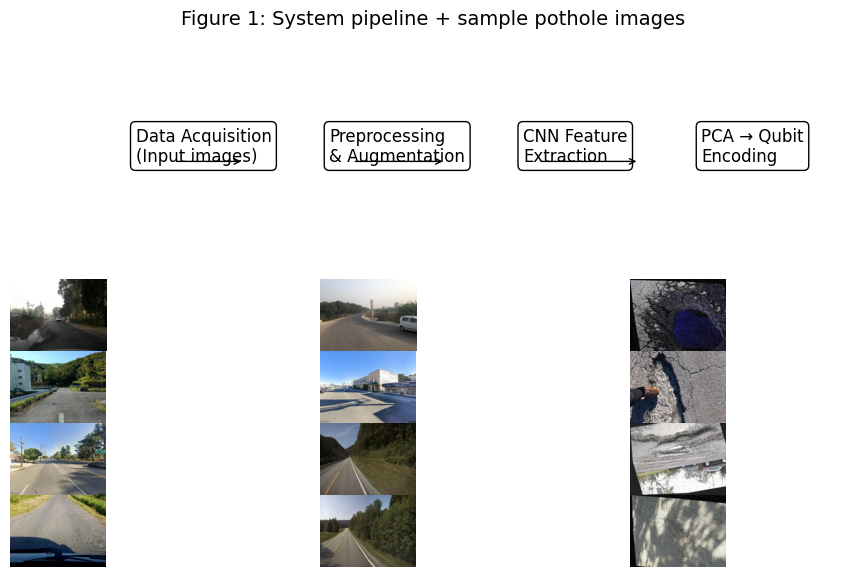

Saved: exp/figures/fig1_pipeline.png


In [21]:
# Fig 1: pipeline + sample images grid
import os
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

os.makedirs("exp/figures", exist_ok=True)
OUT = "exp/figures/fig1_pipeline.png"

# Basic linear flow diagram (matplotlib) + thumbnails below.
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111); ax.axis('off')
ax.text(0.1, 0.8, "Data Acquisition\n(Input images)", fontsize=12, bbox=dict(boxstyle="round", fc="w"))
ax.text(0.35, 0.8, "Preprocessing\n& Augmentation", fontsize=12, bbox=dict(boxstyle="round", fc="w"))
ax.text(0.6, 0.8, "CNN Feature\nExtraction", fontsize=12, bbox=dict(boxstyle="round", fc="w"))
ax.text(0.83, 0.8, "PCA → Qubit\nEncoding", fontsize=12, bbox=dict(boxstyle="round", fc="w"))
ax.annotate("", xy=(0.24,0.8), xytext=(0.15,0.8), arrowprops=dict(arrowstyle="->"))
ax.annotate("", xy=(0.5,0.8), xytext=(0.38,0.8), arrowprops=dict(arrowstyle="->"))
ax.annotate("", xy=(0.75,0.8), xytext=(0.62,0.8), arrowprops=dict(arrowstyle="->"))

# thumbnails
def get_sample_paths(label, K=4):
    if 'image_paths_test' in globals():
        paths = [p for p,l in zip(image_paths_test, y_test) if l==label]
        return paths[:K]
    return []

thumbs = []
for i in range(3):
    sp = get_sample_paths(i, K=4)
    thumbs += sp

# draw thumbnails below
for i,p in enumerate(thumbs):
    try:
        im = Image.open(p).convert("RGB").resize((160,120))
        ax_img = fig.add_axes([0.05 + 0.31*(i//4), 0.05 + 0.12*(i%4), 0.15, 0.12])
        ax_img.imshow(im); ax_img.axis('off')
    except Exception:
        pass

plt.suptitle("Figure 1: System pipeline + sample pothole images", fontsize=14)
plt.savefig(OUT, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", OUT)


Training size 20 (frac 0.01)...
Starting MLP training on cuda


MLP epochs:   0%|          | 0/5 [00:00<?, ?it/s]

MLP done — acc 0.5153, f1 0.3820
Warm-up (first forward) — this may take a few seconds.
Warm-up OK.
Starting QNN training (TorchLayer) on CPU.


QNN epochs:   0%|          | 0/3 [00:00<?, ?it/s]

epoch 1/3:   0%|          | 0/3 [00:00<?, ?it/s]

...

QNN epochs:   0%|          | 0/3 [00:00<?, ?it/s]

epoch 1/3:   0%|          | 0/257 [00:00<?, ?it/s]

epoch 2/3:   0%|          | 0/257 [00:00<?, ?it/s]

epoch 3/3:   0%|          | 0/257 [00:00<?, ?it/s]

QNN done — acc 0.8673, f1 0.8665, time 50.9s


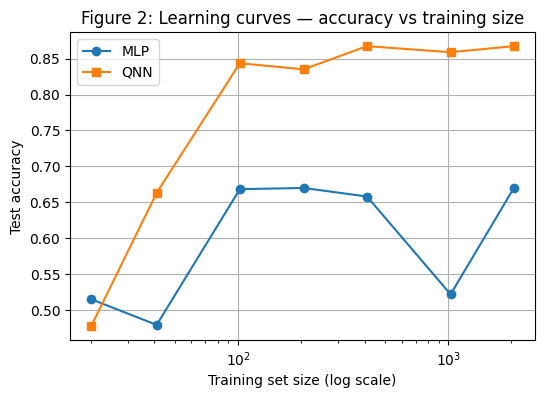

Saved: exp/figures/fig2_learning_curves.png


In [22]:
# Fig 2: learning curves (accuracy vs training size)
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import joblib

OUT = "exp/figures/fig2_learning_curves.png"
fractions = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
mlp_accs = []
qnn_accs = []

# helper wrappers: assume train_mlp_single & train_qnn_torchlayer_single exist
for frac in fractions:
    # subsample training data
    N = max(12, int(len(X_train)*frac))
    idx = np.random.RandomState(42).choice(len(X_train), N, replace=False)
    Xtr, ytr = X_train[idx], y_train[idx]
    print(f"Training size {N} (frac {frac})...")
    mlp_res = _call_train_mlp_flexible(Xtr, ytr, X_val, y_val, X_test, y_test, mlp_epochs=5)
    qnn_res = _call_train_qnn_flexible(Xtr, ytr, X_val, y_val, X_test, y_test, qnn_epochs=3, qnn_batch_size=8, qnn_lr=None)
    mlp_accs.append(mlp_res['acc'])
    qnn_accs.append(qnn_res['acc'])

plt.figure(figsize=(6,4))
plt.plot([max(12,int(len(X_train)*f)) for f in fractions], mlp_accs, marker='o', label='MLP')
plt.plot([max(12,int(len(X_train)*f)) for f in fractions], qnn_accs, marker='s', label='QNN')
plt.xscale('log')
plt.xlabel("Training set size (log scale)")
plt.ylabel("Test accuracy")
plt.title("Figure 2: Learning curves — accuracy vs training size")
plt.legend(); plt.grid(True)
plt.savefig(OUT, dpi=300, bbox_inches='tight'); plt.show()
print("Saved:", OUT)


In [23]:
# Cell A: run three experiment regimes (DEV/speed settings) and save to exp/
# Adjust n_runs / epochs if you want more reliable stats (n_runs>=5).
import os, joblib, time

os.makedirs("exp", exist_ok=True)
# DEV settings (fast)
dev_cfg = {
    "n_runs": 3,          # 3 repeats for quick summary — increase to 5–10 for final stats
    "mlp_epochs": 6,      # small for speed
    "qnn_epochs": 4,      # small for speed
    "qnn_batch_size": 16,
}

print("DEV run settings:", dev_cfg)
start = time.time()

# 1) Full dataset (no changes)
print("\n== Running: full dataset ==")
res_full = repeated_experiments_torchlayer(
    n_runs=dev_cfg["n_runs"],
    mlp_epochs=dev_cfg["mlp_epochs"],
    qnn_epochs=dev_cfg["qnn_epochs"],
    qnn_batch_size=dev_cfg["qnn_batch_size"]
)
joblib.dump(res_full, "exp/results_full.joblib")
print("Saved exp/results_full.joblib")

# 2) Low-data: keep only 10% of training set
print("\n== Running: low-data (10%) ==")
res_low = repeated_experiments_torchlayer(
    n_runs=dev_cfg["n_runs"],
    low_frac=0.10,
    mlp_epochs=dev_cfg["mlp_epochs"],
    qnn_epochs=dev_cfg["qnn_epochs"],
    qnn_batch_size=dev_cfg["qnn_batch_size"]
)
joblib.dump(res_low, "exp/results_low.joblib")
print("Saved exp/results_low.joblib")

# 3) Noisy labels: 20% label noise
print("\n== Running: noisy labels (20%) ==")
res_noisy = repeated_experiments_torchlayer(
    n_runs=dev_cfg["n_runs"],
    noise_frac=0.20,
    mlp_epochs=dev_cfg["mlp_epochs"],
    qnn_epochs=dev_cfg["qnn_epochs"],
    qnn_batch_size=dev_cfg["qnn_batch_size"]
)
joblib.dump(res_noisy, "exp/results_noisy.joblib")
print("Saved exp/results_noisy.joblib")

t = time.time() - start
print(f"\nAll three regimes done in {t/60:.2f} minutes.")


DEV run settings: {'n_runs': 3, 'mlp_epochs': 6, 'qnn_epochs': 4, 'qnn_batch_size': 16}

== Running: full dataset ==


Repeated runs:   0%|          | 0/3 [00:00<?, ?it/s]


Run 1/3: Training MLP (epochs=6)...
Starting MLP training on cuda


MLP epochs:   0%|          | 0/6 [00:00<?, ?it/s]

MLP done — acc 0.4779, f1 0.3091
MLP done in 0.0s — acc 0.4779
Run 1/3: Training QNN (epochs=4, batch_size=16)...
Warm-up (first forward) — this may take a few seconds.
Warm-up OK.
Starting QNN training (TorchLayer) on CPU.


...

epoch 1/4:   0%|          | 0/129 [00:00<?, ?it/s]

epoch 2/4:   0%|          | 0/129 [00:00<?, ?it/s]

epoch 3/4:   0%|          | 0/129 [00:00<?, ?it/s]

epoch 4/4:   0%|          | 0/129 [00:00<?, ?it/s]

QNN done — acc 0.8639, f1 0.8625, time 56.1s
QNN done in 59.6s — acc 0.8639

=== Repeated experiments finished ===
Elapsed total: 190.6s
MLP mean±std acc: 0.565 ± 0.049
QNN mean±std acc: 0.864 ± 0.006
Paired t-test on acc: t=-9.082, p=0.012
Saved exp/results_noisy.joblib

All three regimes done in 7.11 minutes.


Loaded exp/results_full.joblib
Loaded exp/results_low.joblib
Loaded exp/results_noisy.joblib


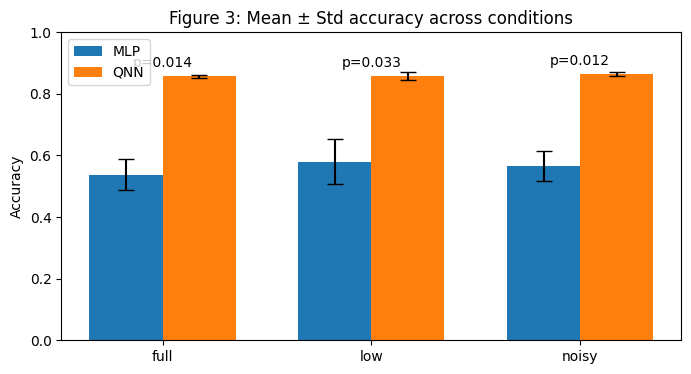

Saved: exp/figures/fig3_bar_conditions.png


In [24]:
# Cell B: Plot Fig.3 (bar plot mean±std across available saved conditions)
import os, joblib, numpy as np, matplotlib.pyplot as plt, scipy.stats as st

files = {
    "full":  "exp/results_full.joblib",
    "low":   "exp/results_low.joblib",
    "noisy": "exp/results_noisy.joblib"
}

loaded = {}
for name, path in files.items():
    if os.path.exists(path):
        loaded[name] = joblib.load(path)
        print("Loaded", path)
    else:
        print("Missing:", path)

if len(loaded)==0:
    raise RuntimeError("No result files found. Run the experiment cell (Cell A) first.")

labels = []
mlp_means=[]; mlp_stds=[]
qnn_means=[]; qnn_stds=[]
p_values = {}

for k,v in loaded.items():
    labels.append(k)
    mlp = np.array(v['mlp_accs'], dtype=float)
    qnn = np.array(v['qnn_accs'], dtype=float)
    mlp_means.append(np.nanmean(mlp))
    mlp_stds.append(0.0 if np.isnan(mlp).all() else float(np.nanstd(mlp)))
    qnn_means.append(np.nanmean(qnn))
    qnn_stds.append(0.0 if np.isnan(qnn).all() else float(np.nanstd(qnn)))
    # paired test (if multiple runs)
    if len(mlp)>1 and len(qnn)>1:
        t,p = st.ttest_rel(mlp, qnn)
        p_values[k] = p
    else:
        p_values[k] = np.nan

# plot grouped bars
x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(8,4))
plt.bar(x - width/2, mlp_means, width, yerr=mlp_stds, capsize=6, label='MLP')
plt.bar(x + width/2, qnn_means, width, yerr=qnn_stds, capsize=6, label='QNN')
plt.xticks(x, labels); plt.ylim(0,1); plt.ylabel("Accuracy")
plt.title("Figure 3: Mean ± Std accuracy across conditions")
plt.legend()

# annotate p-values
for i, lab in enumerate(labels):
    pv = p_values.get(lab, np.nan)
    txt = f"p={pv:.3f}" if not np.isnan(pv) else "p=NA"
    plt.text(i, max(mlp_means[i], qnn_means[i]) + 0.03, txt, ha='center')

out = "exp/figures/fig3_bar_conditions.png"
os.makedirs(os.path.dirname(out), exist_ok=True)
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", out)


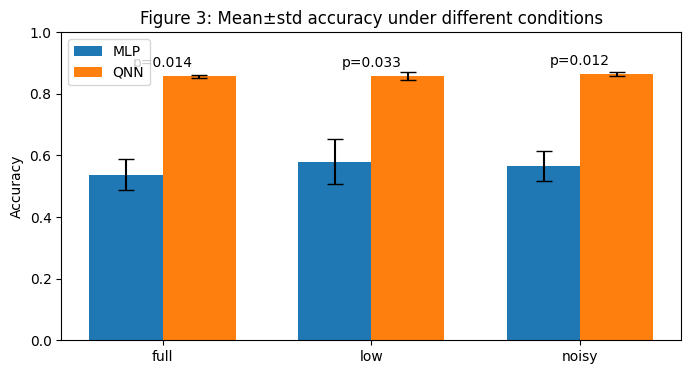

Saved: exp/figures/fig3_bar_conditions.png


In [25]:
# Fig 3: bar plot mean±std for multiple experiment conditions
import joblib, numpy as np, matplotlib.pyplot as plt, scipy.stats as st, os
OUT = "exp/figures/fig3_bar_conditions.png"
conds = {}
# load if exists
for name in ["full","low","noisy"]:
    path = f"exp/results_{name}.joblib"
    if os.path.exists(path):
        conds[name] = joblib.load(path)
    else:
        print("Missing:", path, "-> run and save experiments as exp/results_<name>.joblib")

# If available, compute means and p-values (pairwise)
labels = []
mlp_means=[]; mlp_stds=[]
qnn_means=[]; qnn_stds=[]
for k,v in conds.items():
    labels.append(k)
    mlp = np.array(v['mlp_accs']); qnn = np.array(v['qnn_accs'])
    mlp_means.append(np.nanmean(mlp)); mlp_stds.append(np.nanstd(mlp))
    qnn_means.append(np.nanmean(qnn)); qnn_stds.append(np.nanstd(qnn))

x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(8,4))
plt.bar(x - width/2, mlp_means, width, yerr=mlp_stds, label='MLP', capsize=6)
plt.bar(x + width/2, qnn_means, width, yerr=qnn_stds, label='QNN', capsize=6)
plt.xticks(x, labels); plt.ylim(0,1); plt.ylabel("Accuracy")
plt.title("Figure 3: Mean±std accuracy under different conditions")
plt.legend()

# compute pairwise paired t-test and annotate p-values above bars
for i,k in enumerate(labels):
    mlp = np.array(conds[k]['mlp_accs']); qnn = np.array(conds[k]['qnn_accs'])
    if len(mlp)>1 and len(qnn)>1:
        t,p = st.ttest_rel(mlp,qnn)
        plt.text(i, max(mlp_means[i], qnn_means[i]) + 0.03, f"p={p:.3f}", ha='center')
    else:
        plt.text(i, max(mlp_means[i], qnn_means[i]) + 0.03, "p=NA", ha='center')

plt.savefig(OUT, dpi=300, bbox_inches='tight'); plt.show()
print("Saved:", OUT)


In [26]:
# === Cell: recreate qnn_model and compute logits_q/probs_q ===
import torch, numpy as np
from scipy.special import softmax
print("Recreating qnn_model and computing logits on X_test...")

# Ensure required names exist
for name in ("qlayer","n_qubits","n_classes","HybridQNN_TorchLayer"):
    if name not in globals():
        raise RuntimeError(f"Required object '{name}' not found in globals. Re-run cell that defines it (Cell 7/8).")

# 1) instantiate model (CPU inference)
qnn_model = HybridQNN_TorchLayer(qlayer=qlayer, n_qubits=n_qubits, n_classes=n_classes)
qnn_model.eval()
print("qnn_model created:", qnn_model)

# 2) If you saved trained weights earlier, load them here (optional)
# try:
#     ckpt = torch.load("exp/models/qnn_torchlayer.pth", map_location='cpu')
#     qnn_model.load_state_dict(ckpt['state_dict'])
#     print("Loaded checkpoint exp/models/qnn_torchlayer.pth")
# except Exception:
#     print("No checkpoint loaded (ok if you didn't save).")

# 3) compute logits on X_test
if "X_test" not in globals():
    raise RuntimeError("X_test not found. Recreate processed dataset arrays first.")

Xte = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    logits_q_t = qnn_model(Xte)          # torch tensor (N_test, n_classes)
logits_q = logits_q_t.cpu().numpy()
print("logits_q shape:", logits_q.shape)

# 4) softmax -> probs_q
probs_q = softmax(logits_q, axis=1)
print("probs_q shape:", probs_q.shape)


Recreating qnn_model and computing logits on X_test...
qnn_model created: HybridQNN_TorchLayer(
  (qlayer): <Quantum Torch Layer: func=qnode_torch>
  (fc): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=3, bias=True)
  )
)
logits_q shape: (588, 3)
probs_q shape: (588, 3)


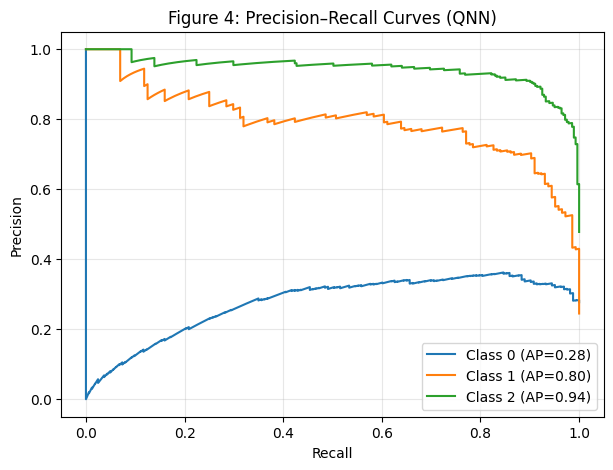

Saved: exp/figures/fig4_pr_curve.png


In [27]:
# === Cell: Figure 4 — Precision-Recall curves (QNN) ===
import os
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np
os.makedirs("exp/figures", exist_ok=True)

if 'probs_q' not in globals():
    raise RuntimeError("probs_q not found — run the qnn logits cell first.")

OUT = "exp/figures/fig4_pr_curve.png"
n_classes = probs_q.shape[1]

plt.figure(figsize=(7,5))
for c in range(n_classes):
    y_true_c = (y_test == c).astype(int)
    prec, rec, _ = precision_recall_curve(y_true_c, probs_q[:, c])
    ap = average_precision_score(y_true_c, probs_q[:, c])
    plt.plot(rec, prec, label=f"Class {c} (AP={ap:.2f})")

plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Figure 4: Precision–Recall Curves (QNN)")
plt.legend(loc="best"); plt.grid(alpha=0.3)
plt.savefig(OUT, dpi=300, bbox_inches='tight'); plt.show()
print("Saved:", OUT)


Embedding shape (used for visualization): (588, 6)
UMAP not available or failed: No module named 'umap' -> falling back to t-SNE (slower).
Used t-SNE for dimensionality reduction.


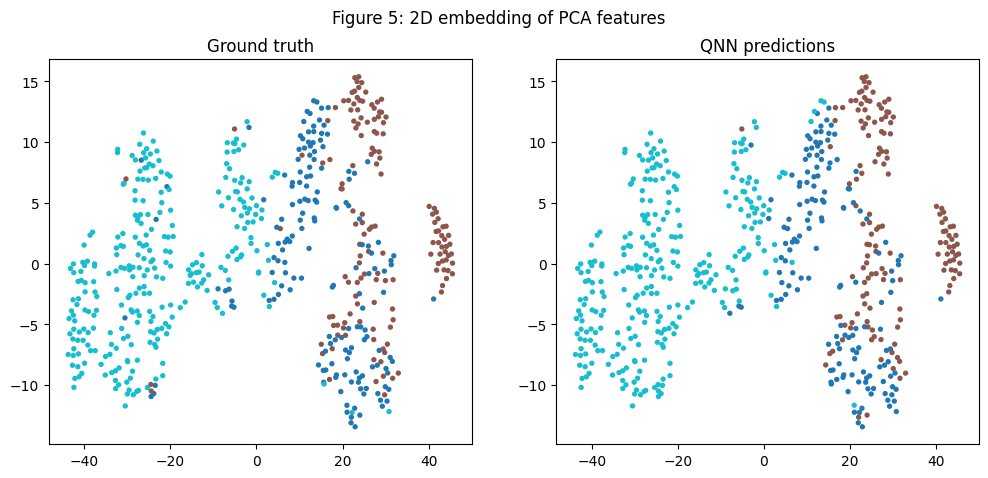

Saved: exp/figures/fig5_umap.png


In [28]:
# === Cell: Figure 5 — UMAP (or t-SNE fallback) of PCA embeddings ===
import os, numpy as np, matplotlib.pyplot as plt
os.makedirs("exp/figures", exist_ok=True)
OUT = "exp/figures/fig5_umap.png"

if 'X_reduced' not in globals():
    raise RuntimeError("X_reduced not found. Re-run PCA / embedding cell to create X_reduced.")

# select embeddings for the test split
emb = X_reduced[test_idx] if 'test_idx' in globals() else X_reduced
print("Embedding shape (used for visualization):", emb.shape)

# try umap, else fallback to t-SNE
use_umap = True
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42)
    emb2d = reducer.fit_transform(emb)
    print("Used UMAP for dimensionality reduction.")
except Exception as e:
    print("UMAP not available or failed:", e, "-> falling back to t-SNE (slower).")
    from sklearn.manifold import TSNE
    reducer = TSNE(n_components=2, init='pca', random_state=42)
    emb2d = reducer.fit_transform(emb)
    print("Used t-SNE for dimensionality reduction.")

# plot GT and predictions
fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].scatter(emb2d[:,0], emb2d[:,1], c=y_test, s=8, cmap='tab10')
axes[0].set_title("Ground truth")
if 'preds' in globals():
    axes[1].scatter(emb2d[:,0], emb2d[:,1], c=preds, s=8, cmap='tab10')
    axes[1].set_title("QNN predictions")
else:
    axes[1].text(0.5,0.5,"No `preds` found; run evaluation to populate preds", ha='center')
    axes[1].set_title("Predictions missing")
plt.suptitle("Figure 5: 2D embedding of PCA features")
plt.savefig(OUT, dpi=300, bbox_inches='tight'); plt.show()
print("Saved:", OUT)


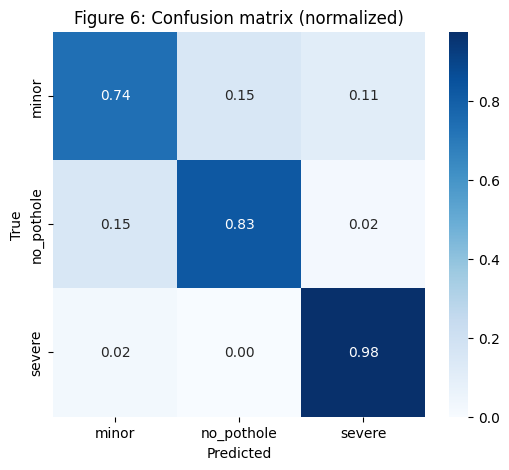

Saved: exp/figures/fig6_confusion.png


In [29]:
# Fig 6: confusion heatmap
import seaborn as sns, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
OUT = "exp/figures/fig6_confusion.png"

cm = confusion_matrix(y_test, preds)
cmn = cm.astype('float')/cm.sum(axis=1)[:,None]
plt.figure(figsize=(6,5))
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=(dataset.classes if 'dataset' in globals() else None),
            yticklabels=(dataset.classes if 'dataset' in globals() else None))
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Figure 6: Confusion matrix (normalized)")
plt.savefig(OUT, dpi=300, bbox_inches='tight'); plt.show()
print("Saved:", OUT)


In [30]:
pip install grad-cam

Note: you may need to restart the kernel to use updated packages.


Device for Grad-CAM: cuda
No backbone_model found — using pretrained ResNet50 as fallback (visualization only).


C:\Users\sriva\anaconda3\envs\pothole-qml\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\sriva\anaconda3\envs\pothole-qml\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Selected Grad-CAM target layer: layer4.2.conv3
GradCAM constructor kwargs: {}
GradCAM object created: <pytorch_grad_cam.grad_cam.GradCAM object at 0x000001B9CEAB4E50>
Selected samples per class (counts): {2: 4, 1: 4, 0: 4}
Total selected images: 12
Saved overlay 1/12 -> exp/figures/fig7_325_jpg.rf.c2b2a141f5c31c1a61e6f1fb4ab81f3f_cam.png
Saved overlay 2/12 -> exp/figures/fig7_63_jpg.rf.c1f5641fb3abaa7fefe03d791d39b5ab_cam.png
Saved overlay 3/12 -> exp/figures/fig7_Norway_001178_cam.png
Saved overlay 4/12 -> exp/figures/fig7_Japan_006120_cam.png
Saved overlay 5/12 -> exp/figures/fig7_305_cam.png
Saved overlay 6/12 -> exp/figures/fig7_147_jpg.rf.8389dbcc3a249ee19c85d7347938e586_cam.png
Saved overlay 7/12 -> exp/figures/fig7_United_States_004468_cam.png
Saved overlay 8/12 -> exp/figures/fig7_Norway_008007_cam.png
Saved overlay 9/12 -> exp/figures/fig7_Japan_001098_cam.png
Saved overlay 10/12 -> exp/figures/fig7_United_States_002598_cam.png
Saved overlay 11/12 -> exp/figures/fig7_India_006

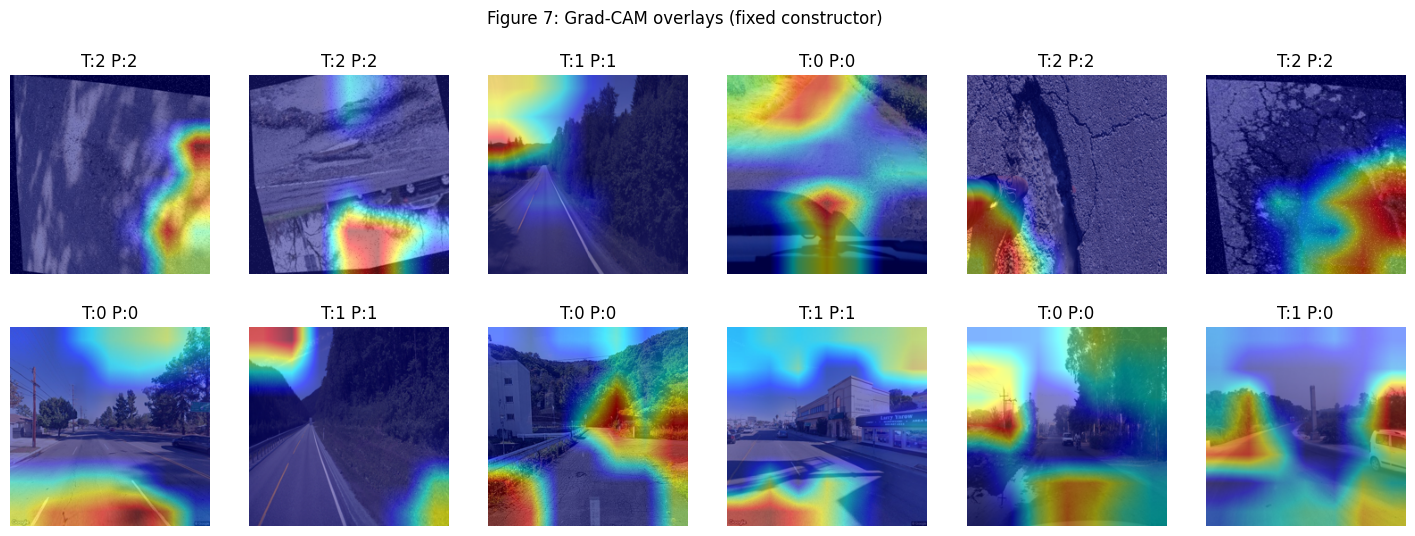

Saved combined Grad-CAM grid to: exp/figures/fig7_samples_grid_fixed.png
Done — Grad-CAM overlays created. If you want Grad-CAM from your exact trained backbone, set 'backbone_model' to that PyTorch model and re-run.


In [31]:
# Robust Grad-CAM cell (handles different grad-cam versions)
import os, inspect, torch, numpy as np
from PIL import Image
import matplotlib.pyplot as plt

os.makedirs("exp/figures", exist_ok=True)
use_cuda_flag = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda_flag else "cpu")
print("Device for Grad-CAM:", device)

# import Grad-CAM with helpful message
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except Exception as e:
    raise RuntimeError("pytorch-grad-cam not available. Install with: pip install grad-cam") from e

# select backbone (prefer existing backbone_model)
conv_model = None
if 'backbone_model' in globals():
    cand = backbone_model
    if any(isinstance(m, torch.nn.Conv2d) for m in cand.modules()):
        conv_model = cand
        print("Using existing backbone_model from globals.")
if conv_model is None:
    print("No backbone_model found — using pretrained ResNet50 as fallback (visualization only).")
    import torchvision.models as models
    conv_model = models.resnet50(pretrained=True)

conv_model = conv_model.to(device)
conv_model.eval()

# pick last conv layer automatically
target_layer = None
for name, module in reversed(list(conv_model.named_modules())):
    if isinstance(module, torch.nn.Conv2d):
        target_layer = module
        target_layer_name = name
        break
if target_layer is None:
    raise RuntimeError("No Conv2d layer found in conv_model — cannot run Grad-CAM.")
print("Selected Grad-CAM target layer:", target_layer_name)

# Build GradCAM with a signature-aware call (some versions use 'use_cuda', others expect device)
cam_ctor_sig = inspect.signature(GradCAM.__init__)
cam_kwargs = {}
# __init__ parameters include 'self' so skip it when checking keys
params = list(cam_ctor_sig.parameters.keys())
# Common names: 'use_cuda' or 'device'
if 'use_cuda' in params:
    cam_kwargs['use_cuda'] = bool(use_cuda_flag)
elif 'device' in params:
    cam_kwargs['device'] = str(device)  # some versions accept device as string
# else no extra kwargs required

print("GradCAM constructor kwargs:", cam_kwargs)

# instantiate cam
cam = GradCAM(model=conv_model, target_layers=[target_layer], **cam_kwargs)
print("GradCAM object created:", cam)

# Prepare sample list (balanced selection per class)
if 'image_paths_test' not in globals():
    raise RuntimeError("image_paths_test not found. Recreate it from your dataset (use dataset.samples and test_idx).")

K_per_class = 4
sel_paths = []
counts = {}
for p, y in zip(image_paths_test, y_test):
    counts.setdefault(int(y), 0)
    if counts[int(y)] < K_per_class:
        sel_paths.append((p, int(y)))
        counts[int(y)] += 1
    if sum(counts.values()) >= K_per_class * len(counts):
        break

print("Selected samples per class (counts):", counts)
print("Total selected images:", len(sel_paths))
if len(sel_paths) == 0:
    raise RuntimeError("No sample images found in image_paths_test for Grad-CAM.")

# transforms and device
import torchvision.transforms as T
preprocess = T.Compose([T.Resize((224,224)), T.ToTensor(),
                        T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])

overlays = []
titles = []
for idx, (p, y_true) in enumerate(sel_paths):
    try:
        img_pil = Image.open(p).convert("RGB").resize((224,224))
        img_np = np.array(img_pil).astype(np.float32) / 255.0
        input_tensor = preprocess(img_pil).unsqueeze(0).to(device)

        # decide target class: if preds available and file is in image_paths_test, use predicted else true
        pred_label = None
        if 'preds' in globals():
            try:
                # find index in image_paths_test
                i = image_paths_test.index(p)
                pred_label = int(preds[i])
            except Exception:
                pred_label = None

        target_cls = pred_label if pred_label is not None else int(y_true)
        targets = [ClassifierOutputTarget(int(target_cls))]

        # compute cam (some GradCAM versions accept input_tensor keyword or positional)
        mask = cam(input_tensor=input_tensor, targets=targets)[0] if 'input_tensor' in inspect.signature(cam.__call__).parameters else cam(input_tensor, targets=targets)[0]

        vis = show_cam_on_image(img_np, mask, use_rgb=True)
        overlays.append(vis)
        titles.append(f"T:{y_true} P:{pred_label if pred_label is not None else 'NA'}")
        # save single overlay
        base = os.path.splitext(os.path.basename(p))[0]
        out_fp = f"exp/figures/fig7_{base}_cam.png"
        Image.fromarray(vis).save(out_fp)
        print(f"Saved overlay {idx+1}/{len(sel_paths)} ->", out_fp)
    except Exception as e:
        print("Error processing", p, ":", repr(e))

# assemble grid
cols = min(6, len(overlays))
rows = int(np.ceil(len(overlays)/cols)) if len(overlays)>0 else 0
if rows == 0:
    raise RuntimeError("No overlays produced.")
fig, axs = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
axs = axs.flatten() if hasattr(axs, 'flatten') else [axs]
for i in range(rows*cols):
    ax = axs[i]
    ax.axis('off')
    if i < len(overlays):
        ax.imshow(overlays[i])
        ax.set_title(titles[i])
out_grid = "exp/figures/fig7_samples_grid_fixed.png"
plt.suptitle("Figure 7: Grad-CAM overlays (fixed constructor)")
plt.savefig(out_grid, dpi=300, bbox_inches='tight'); plt.show()
print("Saved combined Grad-CAM grid to:", out_grid)

# cleanup
try:
    del cam
    torch.cuda.empty_cache()
except Exception:
    pass
print("Done — Grad-CAM overlays created. If you want Grad-CAM from your exact trained backbone, set 'backbone_model' to that PyTorch model and re-run.")


In [32]:
# Cell A: safe QNode draw → write textual circuit to UTF-8 file
import pennylane as qml
import numpy as np
import os

os.makedirs("exp/figures", exist_ok=True)
OUT_TXT = "exp/figures/fig8_circuit.txt"

# sanity checks
if 'n_qubits' not in globals() or 'n_layers' not in globals():
    raise RuntimeError("n_qubits or n_layers not defined. Re-run the PCA / config cells first.")

dev = qml.device("default.qubit", wires=n_qubits)

# define qnode with explicit parameter order (weights, inputs)
@qml.qnode(dev)
def _draw_qnode(weights, inputs):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Build compatible dummy args
dummy_weights = np.zeros((n_layers, n_qubits, 3))
dummy_inputs  = np.zeros(n_qubits)

# Try to draw (explicit arg order)
txt = None
try:
    drawer = qml.draw(_draw_qnode)
    txt = drawer(dummy_weights, dummy_inputs)
    if not isinstance(txt, str):
        txt = str(txt)
    with open(OUT_TXT, "w", encoding="utf-8") as f:
        f.write(txt)
    print("Saved textual circuit to", OUT_TXT)
except Exception as e:
    # try alternate call order (some qml.draw variants differ)
    try:
        drawer2 = qml.draw(_draw_qnode)
        txt2 = drawer2(dummy_inputs, dummy_weights)
        txt2 = str(txt2)
        with open(OUT_TXT, "w", encoding="utf-8") as f:
            f.write(txt2)
        print("Saved textual circuit to", OUT_TXT, "via alternate call")
    except Exception as e2:
        print("Both qml.draw attempts failed. Tracebacks follow.")
        import traceback
        traceback.print_exc()
        raise RuntimeError("Failed to draw QNode. Paste the tracebacks here so I can adapt.")


Saved textual circuit to exp/figures/fig8_circuit.txt


In [33]:
# Cell B: render textual circuit file -> PNG (robust to Pillow versions)
from PIL import Image, ImageDraw, ImageFont
import textwrap, os

TXT = "exp/figures/fig8_circuit.txt"
OUT_PNG = "exp/figures/fig8_circuit.png"

if not os.path.exists(TXT):
    raise RuntimeError(f"Text circuit {TXT} not found. Run the QNode-draw cell first.")

txt = open(TXT, "r", encoding="utf-8").read().strip()
if len(txt) == 0:
    txt = "Circuit text empty — qml.draw may have failed. Re-run the draw cell and paste the printed error here."

# Wrap long lines for better rendering
lines = []
for line in txt.splitlines():
    lines += textwrap.wrap(line, width=120) or [""]

# choose monospace font if available
try:
    font = ImageFont.truetype("DejaVuSansMono.ttf", 12)
except Exception:
    font = ImageFont.load_default()

# measure text bounding box using ImageDraw.textbbox (robust)
# create a temporary image to measure text sizes
temp_img = Image.new("RGB", (10, 10))
draw = ImageDraw.Draw(temp_img)

line_heights = []
max_width = 0
for line in lines:
    try:
        bbox = draw.textbbox((0,0), line, font=font)  # returns (x0,y0,x1,y1)
        w = bbox[2] - bbox[0]
        h = bbox[3] - bbox[1]
    except Exception:
        # fallback older pillow
        w, h = draw.textsize(line, font=font)
    line_heights.append(h)
    if w > max_width:
        max_width = w

line_height = max(line_heights) if line_heights else (font.getmetrics()[0] if hasattr(font, "getmetrics") else 14)
padding = 10
img_w = max(200, max_width + padding*2)
img_h = max(100, sum(line_heights) + padding*2 + len(lines)*2)

img = Image.new("RGB", (img_w, img_h), color="white")
draw = ImageDraw.Draw(img)
y = padding
for line in lines:
    try:
        draw.text((padding, y), line, font=font, fill="black")
    except Exception:
        draw.text((padding, y), line, fill="black")
    y += line_height + 2

img.save(OUT_PNG)
print("Saved circuit PNG:", OUT_PNG, " (chars in text:", len(txt), ")")


Saved circuit PNG: exp/figures/fig8_circuit.png  (chars in text: 558 )


In [40]:
# ===============================
# INFERENCE ON NEW RANDOM IMAGES
# ===============================

#from PIL import Image
"""import torchvision.transforms as transforms
import torch
import numpy as np

TEST_DIR = r"D:\test_images"   # <-- CHANGE if needed

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

class_names = ["no_pothole", "minor", "severe"]

model.eval()
feature_extractor.eval()

for img_name in os.listdir(TEST_DIR):
    if not img_name.lower().endswith((".jpg",".png",".jpeg")):
        continue

    img_path = os.path.join(TEST_DIR, img_name)
    img = Image.open(img_path).convert("RGB")

    x = transform(img).unsqueeze(0).to(DEVICE)

    # CNN embedding
    with torch.no_grad():
        feat = feature_extractor(x)
        feat = feat.view(1, -1).cpu().numpy()

    # PCA + scaling
    z = pca.transform(feat)
    z = scaler.transform(z)
    z = (z - z.min()) / (z.max() - z.min()) * np.pi

    # QNN prediction
    z_t = torch.tensor(z, dtype=torch.float32)
    with torch.no_grad():
        logits = model(z_t)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred = np.argmax(probs)

    print(f"\nImage: {img_name}")
    print("Prediction:", class_names[pred])
    print("Confidence:", round(probs[pred]*100, 2), "%")
    """


'import torchvision.transforms as transforms\nimport torch\nimport numpy as np\n\nTEST_DIR = r"D:\test_images"   # <-- CHANGE if needed\n\ntransform = transforms.Compose([\n    transforms.Resize((224,224)),\n    transforms.ToTensor(),\n    transforms.Normalize(\n        mean=[0.485,0.456,0.406],\n        std=[0.229,0.224,0.225]\n    )\n])\n\nclass_names = ["no_pothole", "minor", "severe"]\n\nmodel.eval()\nfeature_extractor.eval()\n\nfor img_name in os.listdir(TEST_DIR):\n    if not img_name.lower().endswith((".jpg",".png",".jpeg")):\n        continue\n\n    img_path = os.path.join(TEST_DIR, img_name)\n    img = Image.open(img_path).convert("RGB")\n\n    x = transform(img).unsqueeze(0).to(DEVICE)\n\n    # CNN embedding\n    with torch.no_grad():\n        feat = feature_extractor(x)\n        feat = feat.view(1, -1).cpu().numpy()\n\n    # PCA + scaling\n    z = pca.transform(feat)\n    z = scaler.transform(z)\n    z = (z - z.min()) / (z.max() - z.min()) * np.pi\n\n    # QNN prediction\n  